# Assignment 1: Simple Linear Regression

1. Read in the "Computers.csv" file & perform any desired EDA.
2. Fit a regression model with target = "price".  Fit your model on the feature with the strongest correlation to price
3. Interpret the model equation
4. Visualize the residuals of your model
5. Make predictions for common values of your feature

In [2]:
import pandas as pd

computers = pd.read_csv(r"C:\Users\linke\Desktop\Python\Regressions\Assignments\Assignments\Computers.csv")

computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


### EDA

In [3]:
df = computers

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   price    6259 non-null   int64
 1   speed    6259 non-null   int64
 2   hd       6259 non-null   int64
 3   ram      6259 non-null   int64
 4   screen   6259 non-null   int64
 5   cd       6259 non-null   str  
 6   multi    6259 non-null   str  
 7   premium  6259 non-null   str  
 8   ads      6259 non-null   int64
 9   trend    6259 non-null   int64
dtypes: int64(7), str(3)
memory usage: 489.1 KB


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'speed'}>,
        <Axes: title={'center': 'hd'}>],
       [<Axes: title={'center': 'ram'}>,
        <Axes: title={'center': 'screen'}>,
        <Axes: title={'center': 'ads'}>],
       [<Axes: title={'center': 'trend'}>, <Axes: >, <Axes: >]],
      dtype=object)

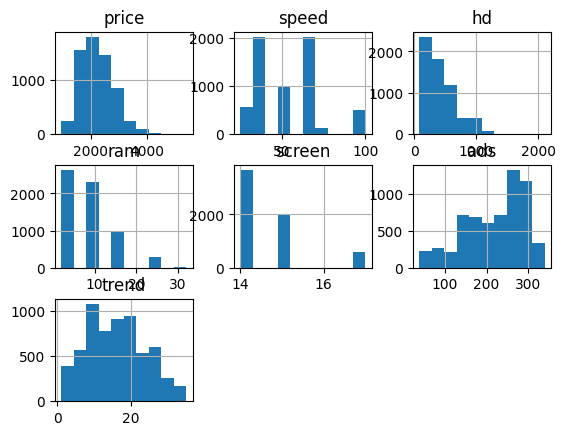

In [4]:
df.hist()

<Axes: xlabel='ram', ylabel='price'>

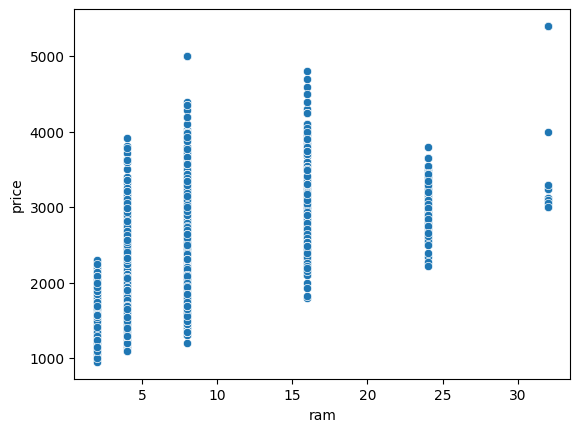

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x="ram", y="price", data=df)

In [14]:
num = df.select_dtypes("number")
corr = num.corr()
corr

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


<Axes: >

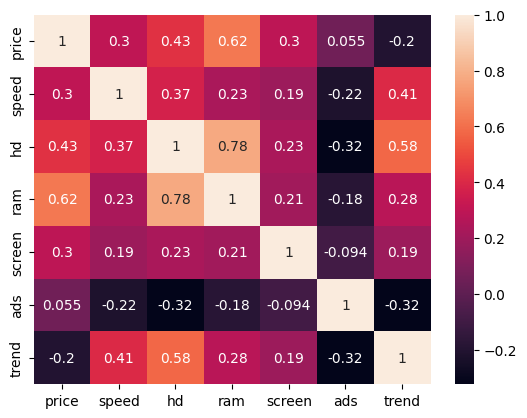

In [17]:
sns.heatmap(df.select_dtypes("number").corr(), annot=True)

<Axes: ylabel='price'>

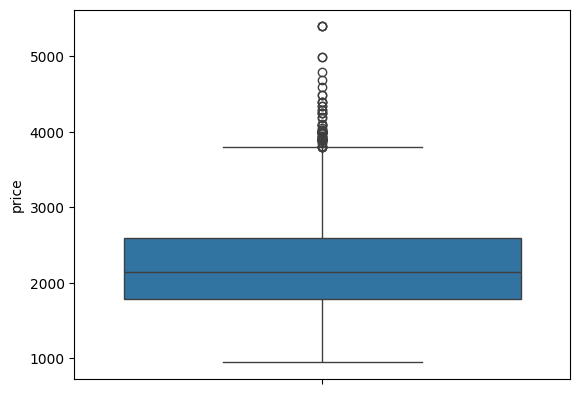

In [15]:
sns.boxplot(df["price"])

In [16]:
df.describe()

,price,speed,hd,ram,screen,ads,trend
count,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000
mean,2219.576610,52.011024,416.601694,8.286947,14.608723,221.301007,15.926985
std,580.803956,21.157735,258.548445,5.631099,0.905115,74.835284,7.873984
min,949.000000,25.000000,80.000000,2.000000,14.000000,39.000000,1.000000
25%,1794.000000,33.000000,214.000000,4.000000,14.000000,162.500000,10.000000
50%,2144.000000,50.000000,340.000000,8.000000,14.000000,246.000000,16.000000
75%,2595.000000,66.000000,528.000000,8.000000,15.000000,275.000000,21.500000
max,5399.000000,100.000000,2100.000000,32.000000,17.000000,339.000000,35.000000


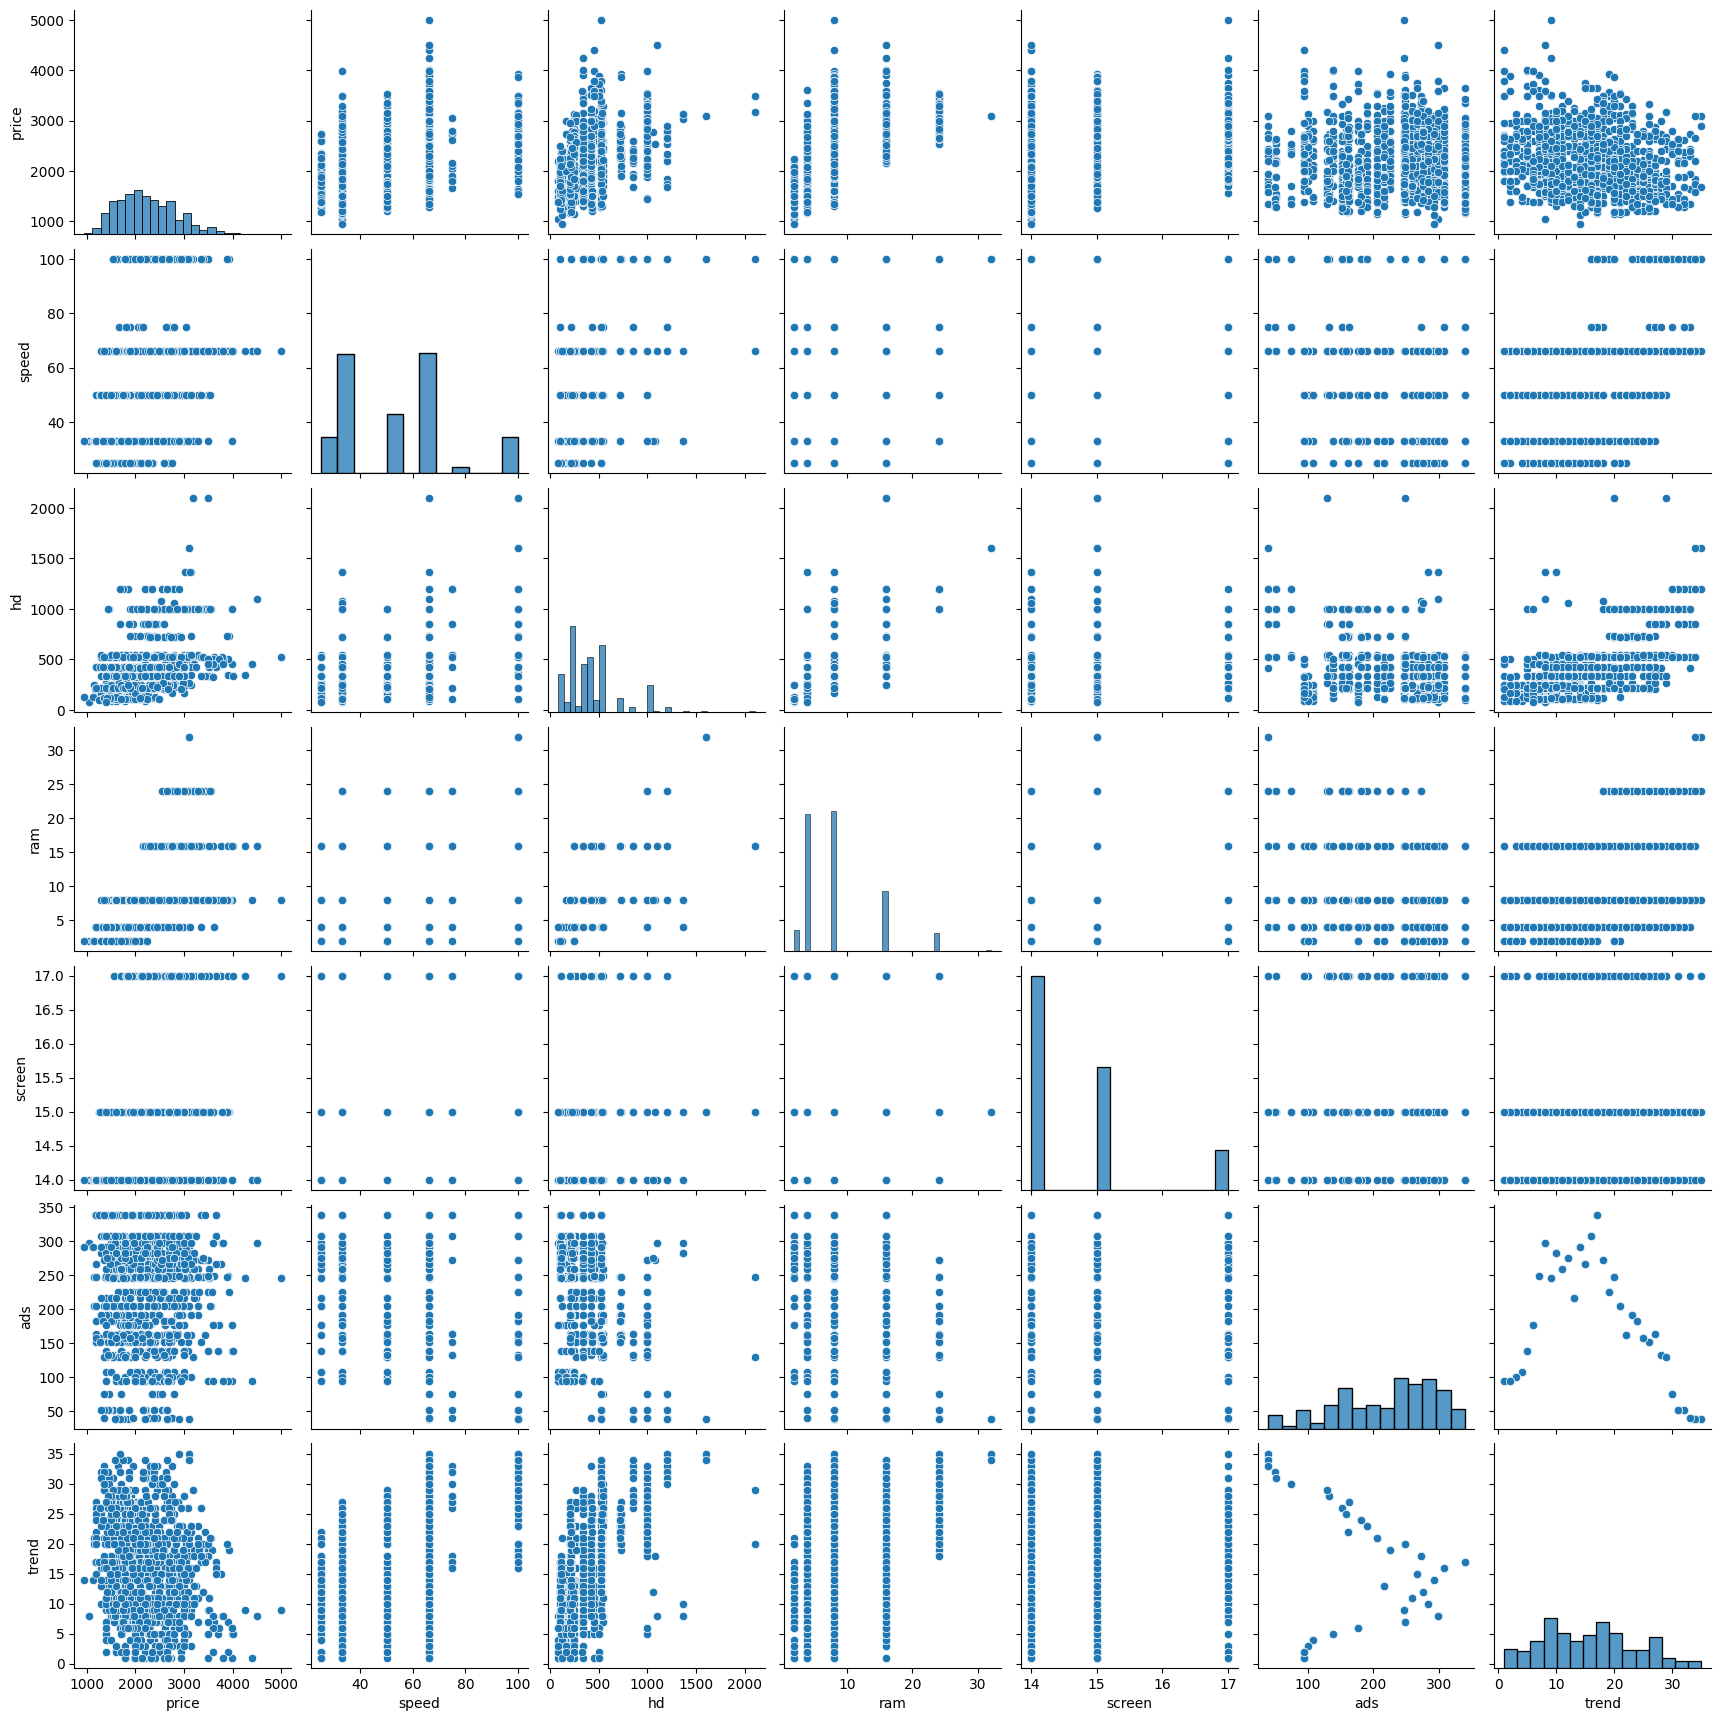

In [18]:
sns.pairplot(num.sample(min(len(num),1000)))
plt.show()


### Model Fitting

In [19]:
df.select_dtypes("number").corr()["price"].sort_values(ascending=False)

price     1.000000
ram       0.622748
hd        0.430258
speed     0.300976
screen    0.296041
ads       0.054540
trend    -0.199987
Name: price, dtype: float64

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
X = df[["ram"]]     # turi būti 2D (double [])
y = df["price"]

In [22]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Best line (grid search approx): price = 1686.473899612093 + 64.33041301627037 * ram


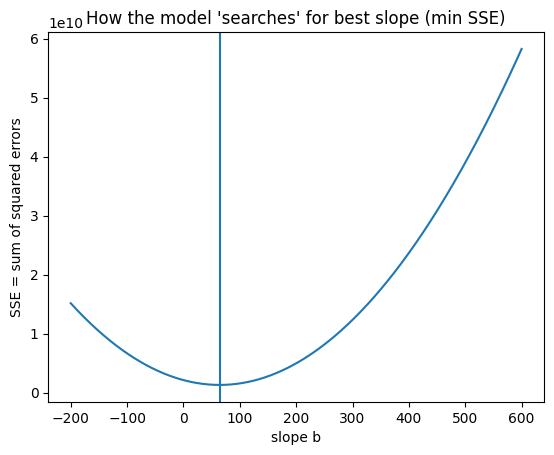

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = df["ram"].to_numpy()
y = df["price"].to_numpy()

mx, my = x.mean(), y.mean()

# pabandom daug skirtingų slope reikšmių
b_grid = np.linspace(-200, 600, 800)   # gali pakeisti ribas jei reikia
sse = []

for b in b_grid:
    a = my - b * mx                  # geriausias a prie šito b
    yhat = a + b * x
    sse.append(((y - yhat) ** 2).sum())

sse = np.array(sse)

best_idx = sse.argmin()
best_b = b_grid[best_idx]
best_a = my - best_b * mx

print("Best line (grid search approx): price =", best_a, "+", best_b, "* ram")

plt.plot(b_grid, sse)
plt.axvline(best_b)
plt.xlabel("slope b")
plt.ylabel("SSE = sum of squared errors")
plt.title("How the model 'searches' for best slope (min SSE)")
plt.show()

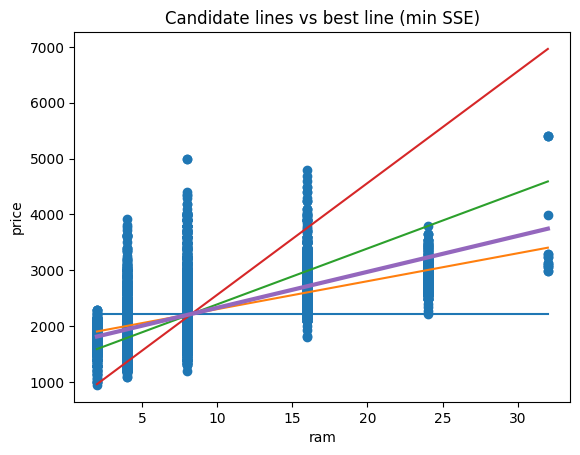

In [24]:
plt.scatter(x, y)

# kelios atsitiktinės linijos (blogos / ok)
for b in [0, 50, 100, 200]:
    a = my - b * mx
    xs = np.array([x.min(), x.max()])
    plt.plot(xs, a + b * xs)

# geriausia (pagal mūsų grid search)
xs = np.array([x.min(), x.max()])
plt.plot(xs, best_a + best_b * xs, linewidth=3)

plt.xlabel("ram")
plt.ylabel("price")
plt.title("Candidate lines vs best line (min SSE)")
plt.show()

### Intepretation:


In [26]:
print(model.intercept_)
print(model.coef_)

1687.2925366972606
[64.23162668]


### Plot Residuals

In [27]:
pred = model.predict(X)

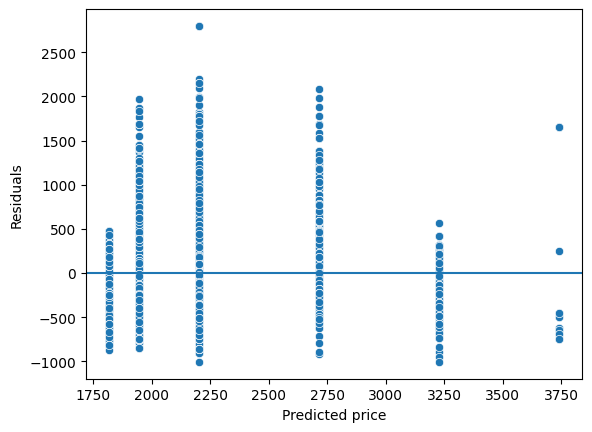

In [28]:
import seaborn as sns

sns.scatterplot(x=pred, y=y - pred)
plt.axhline(0)
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.show()

<Axes: ylabel='Count'>

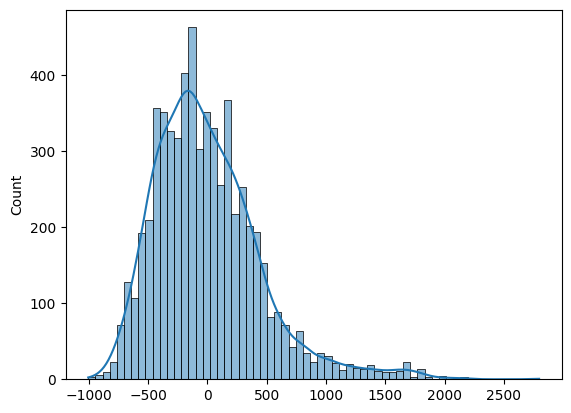

In [29]:
# shows residual normality, bell - good, normal. Makes sense.

res = y - model.predict(X)

import seaborn as sns
sns.histplot(res, kde=True)

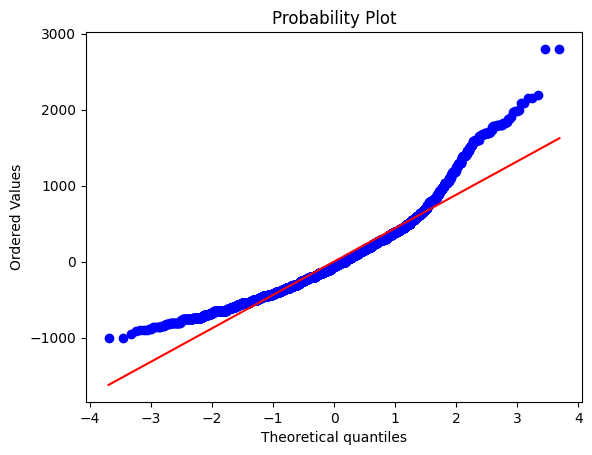

In [30]:
# QQ plot

import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(res, dist="norm", plot=plt)
plt.show()

In [ ]:
#p-value > 0.05 → normal OK, but only for small n (up to 50 is great, larger not great)
#for large n need QQ plot

from scipy.stats import shapiro  

shapiro(res)

c:\Users\linke\Desktop\GitHub\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6259.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9341376177512261), pvalue=np.float64(3.330623835731638e-46))

In [32]:
model.score(X, y)

0.38781537634481045

### Make Predictions with the values below

In [33]:
feature_values = [0, 2, 4, 8, 16, 32, 64]

In [34]:
import pandas as pd

new = pd.DataFrame({"ram":[0,2,4,8,16,32, 64]})
model.predict(new)

array([1687.2925367 , 1815.75579006, 1944.21904343, 2201.14555016,
       2714.99856363, 3742.70459056, 5798.11664443])

In [35]:
df["predicted"] = model.predict(X)

In [36]:
df[["ram","price","predicted"]].head(10)

,ram,price,predicted
0,4,1499,1944.219043
1,2,1795,1815.755790
2,4,1595,1944.219043
3,8,1849,2201.145550
4,16,3295,2714.998564
5,16,3695,2714.998564
6,4,1720,1944.219043
7,2,1995,1815.755790
8,8,2225,2201.145550
9,4,2575,1944.219043


<Axes: xlabel='ram', ylabel='price'>

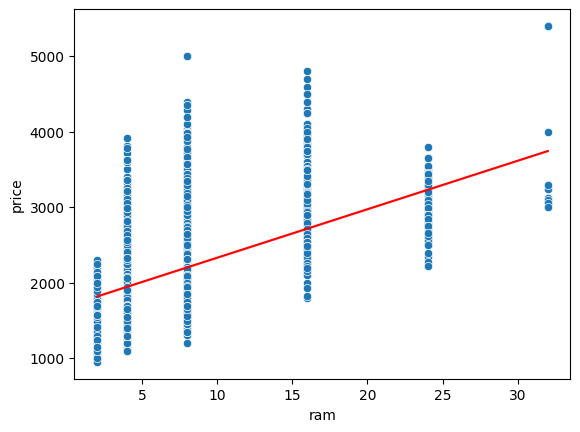

In [37]:
import seaborn as sns

sns.scatterplot(x="ram", y="price", data=df)
sns.lineplot(x="ram", y="predicted", data=df, color="red")

In [38]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

In [39]:
new = pd.DataFrame({"ram":[4,8,16]})
new = sm.add_constant(new)

model_sm.get_prediction(new).summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1944.219043,7.219978,1930.065408,1958.372679,1053.188928,2835.249159
1,2201.145550,5.751965,2189.869725,2212.421375,1310.156501,3092.134600
2,2714.998564,9.742738,2695.899454,2734.097673,1823.876171,3606.120956


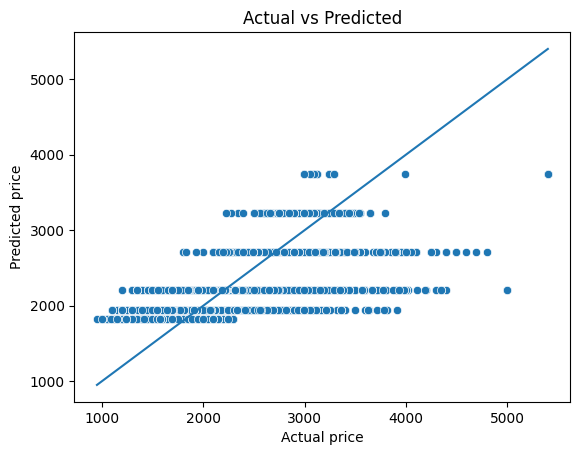

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X)

sns.scatterplot(x=y, y=pred)

# ideali linija (perfect predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()])

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted")
plt.show()

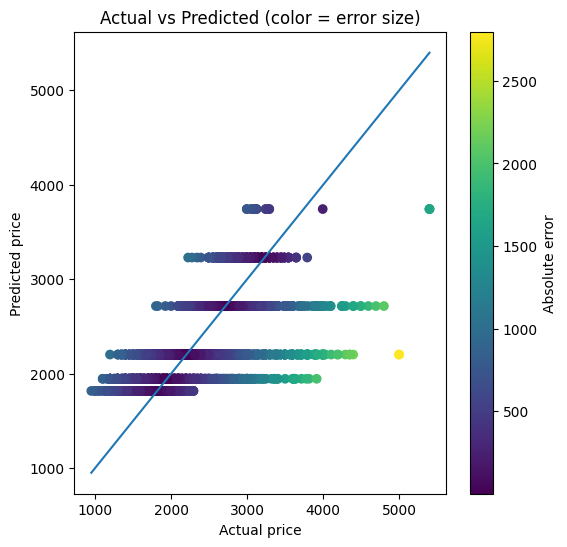

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X)

# klaidos dydis (absolute residual)
errors = np.abs(y - pred)

plt.figure(figsize=(6,6))

plt.scatter(y, pred, c=errors)   # spalva pagal klaidą

# ideali linija
plt.plot([y.min(), y.max()], [y.min(), y.max()])

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted (color = error size)")
plt.colorbar(label="Absolute error")

plt.show()

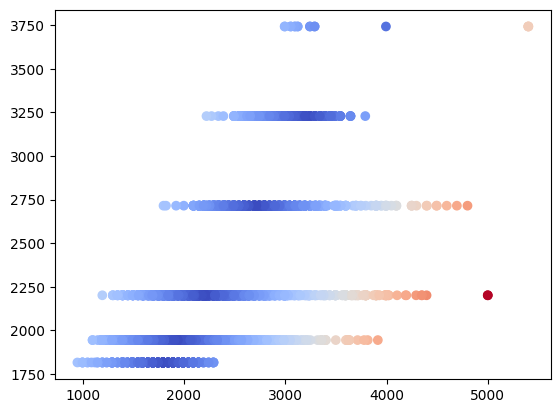

In [42]:
plt.scatter(y, pred, c=errors, cmap="coolwarm")